<a href="https://colab.research.google.com/github/Oliwash254/machine-learning/blob/main/30213_StudentID_CellDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

load zip and extract

In [17]:
from google.colab import files
import zipfile
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

upload zip

In [18]:
uploaded = files.upload()

Saving Data 30213.zip to Data 30213 (1).zip


In [20]:
zip_filename = next(iter(uploaded.keys()))
extract_dir = "/content/data"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Extracted to:", extract_dir)

Extracted to: /content/data


list all images

In [21]:
image_paths = glob.glob(extract_dir + "/**/*.*", recursive=True)
image_paths = [p for p in image_paths if p.lower().endswith((".jpg",".jpeg",".png",".bmp"))]

print("Total images found:", len(image_paths))

Total images found: 7


select three random images + locate Bhammimage

In [22]:
# Select 3 random images for Task 1 & 2
random_images = random.sample(image_paths, 3)
print("Selected images:", random_images)

Selected images: ['/content/data/Data 30213/cells/9343 AM Edges.bmp', '/content/data/Data 30213/cells/10905 JL Edges.bmp', '/content/data/Data 30213/cells/10905 JL.bmp']


In [23]:
# Find Bhammimage.jpeg for Task 3
bham_path = None
for p in image_paths:
    if "bham" in p.lower() or "bhammimage" in p.lower():
        bham_path = p
        break

print("Bhammimage path:", bham_path)

Bhammimage path: /content/data/Data 30213/Bhamimage.jpeg


Helper function to show images

In [24]:
def show(img, title="", cmap="gray"):
    plt.figure(figsize=(4,4))
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()


TASK 1 — Apply Sobel, Prewitt, Roberts, Laplacian

In [28]:
def denoise(img):
    return cv2.GaussianBlur(img, (5,5), 0)

def sobel_edge(img):
    sx = cv2.Sobel(img, cv2.CV_64F, 1, 0)
    sy = cv2.Sobel(img, cv2.CV_64F, 0, 1)
    return cv2.magnitude(sx, sy)

def prewitt_edge(img):
    kernelx = np.array([[1,1,1],[0,0,0],[-1,-1,-1]])
    kernely = np.array([[1,0,-1],[1,0,-1],[1,0,-1]])
    px = cv2.filter2D(img, cv2.CV_64F, kernelx) # Specify CV_64F for output depth
    py = cv2.filter2D(img, cv2.CV_64F, kernely) # Specify CV_64F for output depth
    return cv2.convertScaleAbs(cv2.magnitude(px, py)) # Convert back to uint8 for display

def roberts_edge(img):
    kx = np.array([[1,0],[0,-1]])
    ky = np.array([[0,1],[-1,0]])
    rx = cv2.filter2D(img, cv2.CV_64F, kx) # Specify CV_64F for output depth
    ry = cv2.filter2D(img, cv2.CV_64F, ky) # Specify CV_64F for output depth
    return cv2.convertScaleAbs(cv2.magnitude(rx, ry)) # Convert back to uint8 for display

def laplacian_edge(img):
    lap = cv2.Laplacian(img, cv2.CV_64F)
    return cv2.convertScaleAbs(lap)


run task !

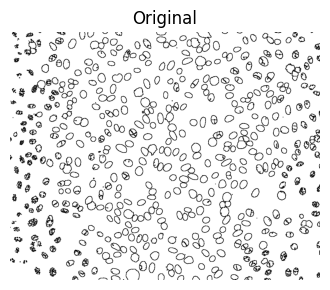

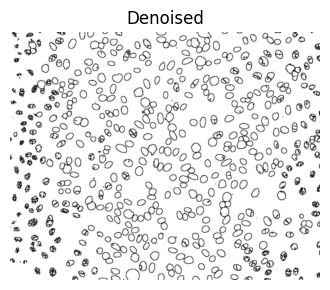

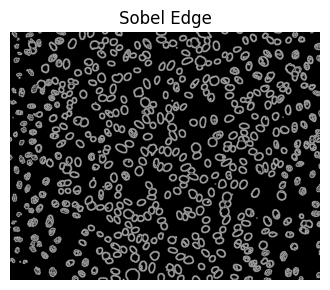

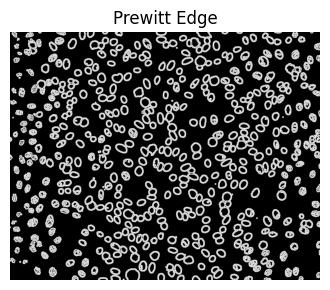

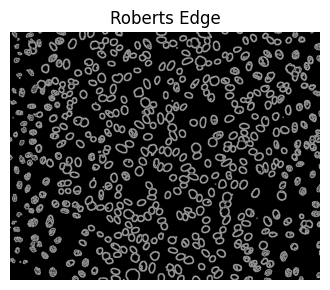

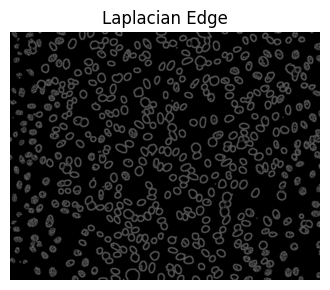

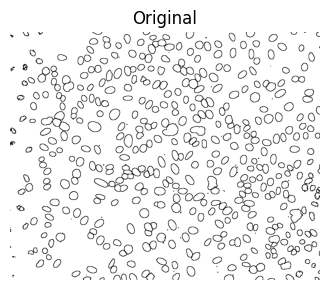

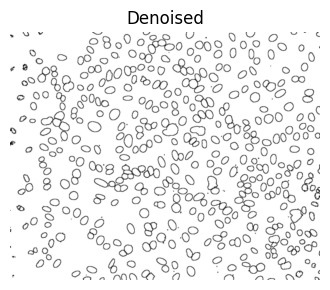

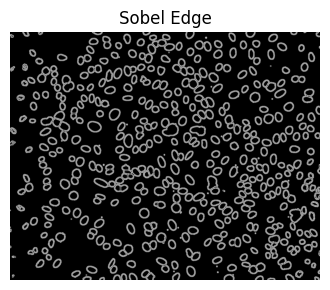

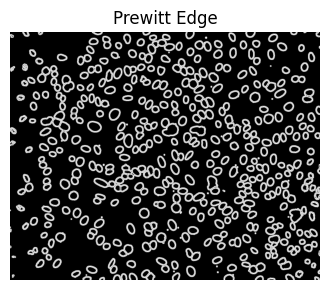

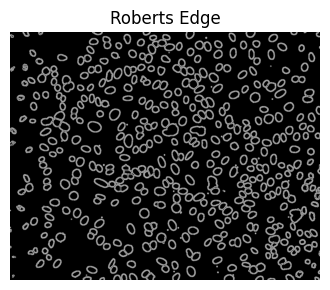

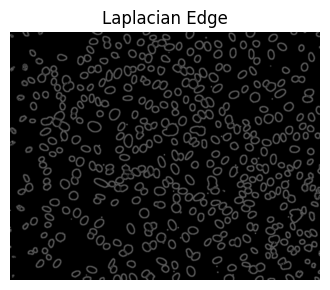

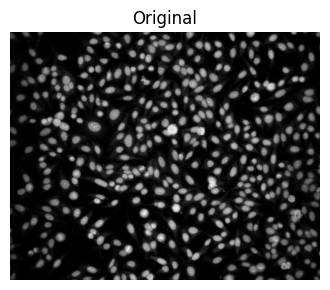

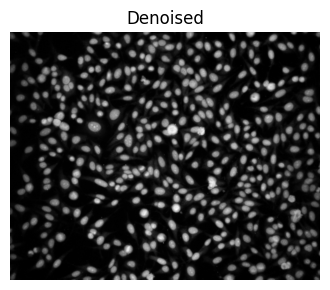

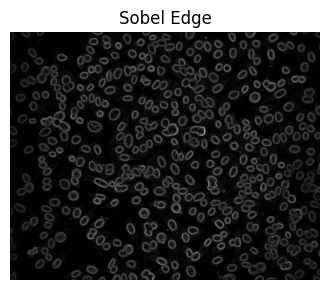

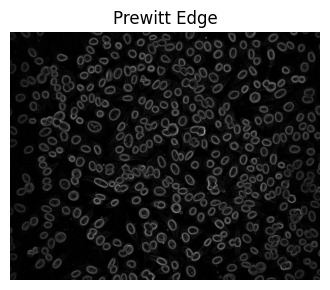

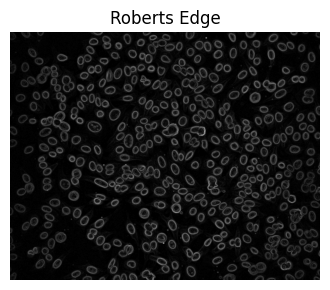

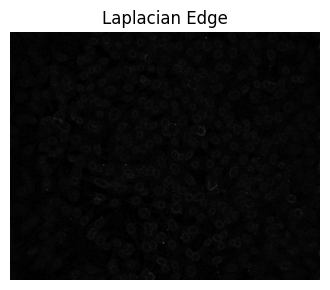

In [29]:
for path in random_images:
    img = cv2.imread(path, 0)
    den = denoise(img)

    show(img, "Original")
    show(den, "Denoised")

    show(sobel_edge(den), "Sobel Edge")
    show(prewitt_edge(den), "Prewitt Edge")
    show(roberts_edge(den), "Roberts Edge")
    show(laplacian_edge(den), "Laplacian Edge")


TASK 2 — Use Scharr Edge Detector

In [30]:
def scharr_edge(img):
    sx = cv2.Scharr(img, cv2.CV_64F, 1, 0)
    sy = cv2.Scharr(img, cv2.CV_64F, 0, 1)
    return cv2.magnitude(sx, sy)


run task 2

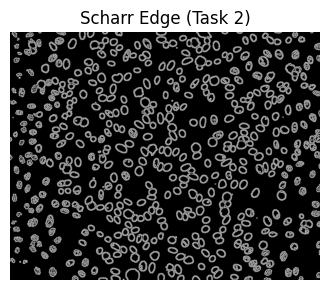

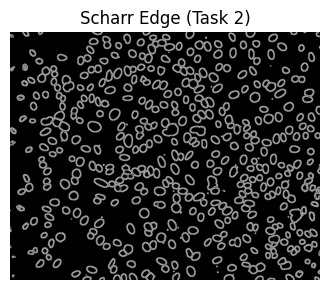

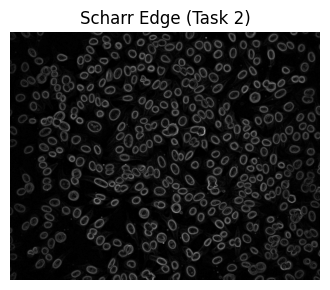

In [31]:
for path in random_images:
    img = cv2.imread(path, 0)
    den = denoise(img)

    show(scharr_edge(den), "Scharr Edge (Task 2)")


TASK 3 — Canny + Hough Transform on Bhammimage.jpeg

1. Canny

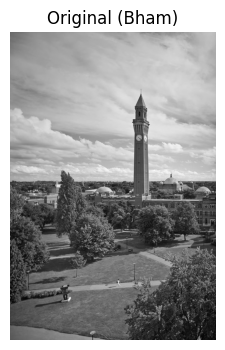

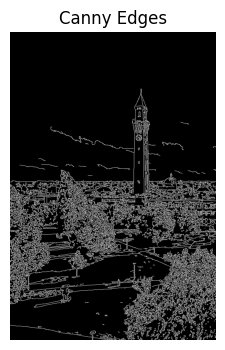

In [32]:
img = cv2.imread(bham_path, 0)
edges = cv2.Canny(img, 100, 200)

show(img, "Original (Bham)")
show(edges, "Canny Edges")


2. Hough Transform (Lines detection)

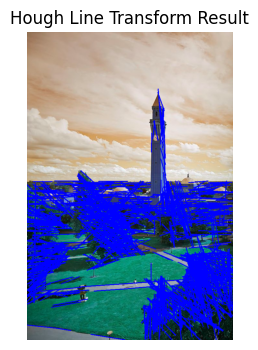

In [33]:
img_color = cv2.imread(bham_path)
lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=80,
                        minLineLength=50, maxLineGap=10)

if lines is not None:
    for line in lines:
        x1,y1,x2,y2 = line[0]
        cv2.line(img_color, (x1,y1), (x2,y2), (0,0,255), 2)

show(img_color, "Hough Line Transform Result")
